# Climate Change in the American Mind (2008–2024)
### A Quantitative Analysis of Public Concern and Climate Policy Attitudes

**Author:** at702 
**Dataset:** Yale Program on Climate Change Communication (CCAM)  
**Date:** June 2026

## Introduction

Climate change is an increasingly important public issue in the United States. Understanding how public attitudes evolve over time can inform communication strategies and policy decisions.

This analysis uses data from the Yale Program on Climate Change Communication's *Climate Change in the American Mind* survey to examine trends in climate concern and policy attitudes from 2008 to 2024.

In [1]:
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

In [3]:
df, meta = pyreadstat.read_sav("CCAM SPSS Data 2008-2024.sav")

## Dataset Overview

The dataset contains survey responses from over 35,000 respondents collected between 2008 and 2024.

Variables analyzed include:
- Climate worry
- Perceived harms of climate change
- Support for climate policies

In [4]:
print(df.shape)
df.head()

(35309, 58)


,case_ID,wave,year,weight_wave,weight_aggregate,happening,cause_original,cause_other_text,cause_recoded,sci_consensus,...,employment,house_head,house_size,house_ages0to1,house_ages2to5,house_ages6to12,house_ages13to17,house_ages18plus,house_type,house_own
0,2.0,1.0,1.0,0.54,0.284224,3.0,1.0,,6.0,4.0,...,2.0,1.0,3.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0
1,3.0,1.0,1.0,0.85,0.447389,2.0,1.0,,6.0,1.0,...,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,4.0,2.0
2,5.0,1.0,1.0,0.49,0.257907,2.0,2.0,,4.0,2.0,...,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0
3,6.0,1.0,1.0,0.29,0.152639,3.0,2.0,,4.0,4.0,...,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0
4,7.0,1.0,1.0,1.29,0.678979,3.0,1.0,,6.0,2.0,...,1.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0


## Research Question 1

How have Americans' levels of concern about climate change changed between 2008 and 2024?

In [5]:
year_map = meta.variable_value_labels['year']

df['year_actual'] = df['year'].map(year_map)
df['year_actual'] = df['year_actual'].astype(int)

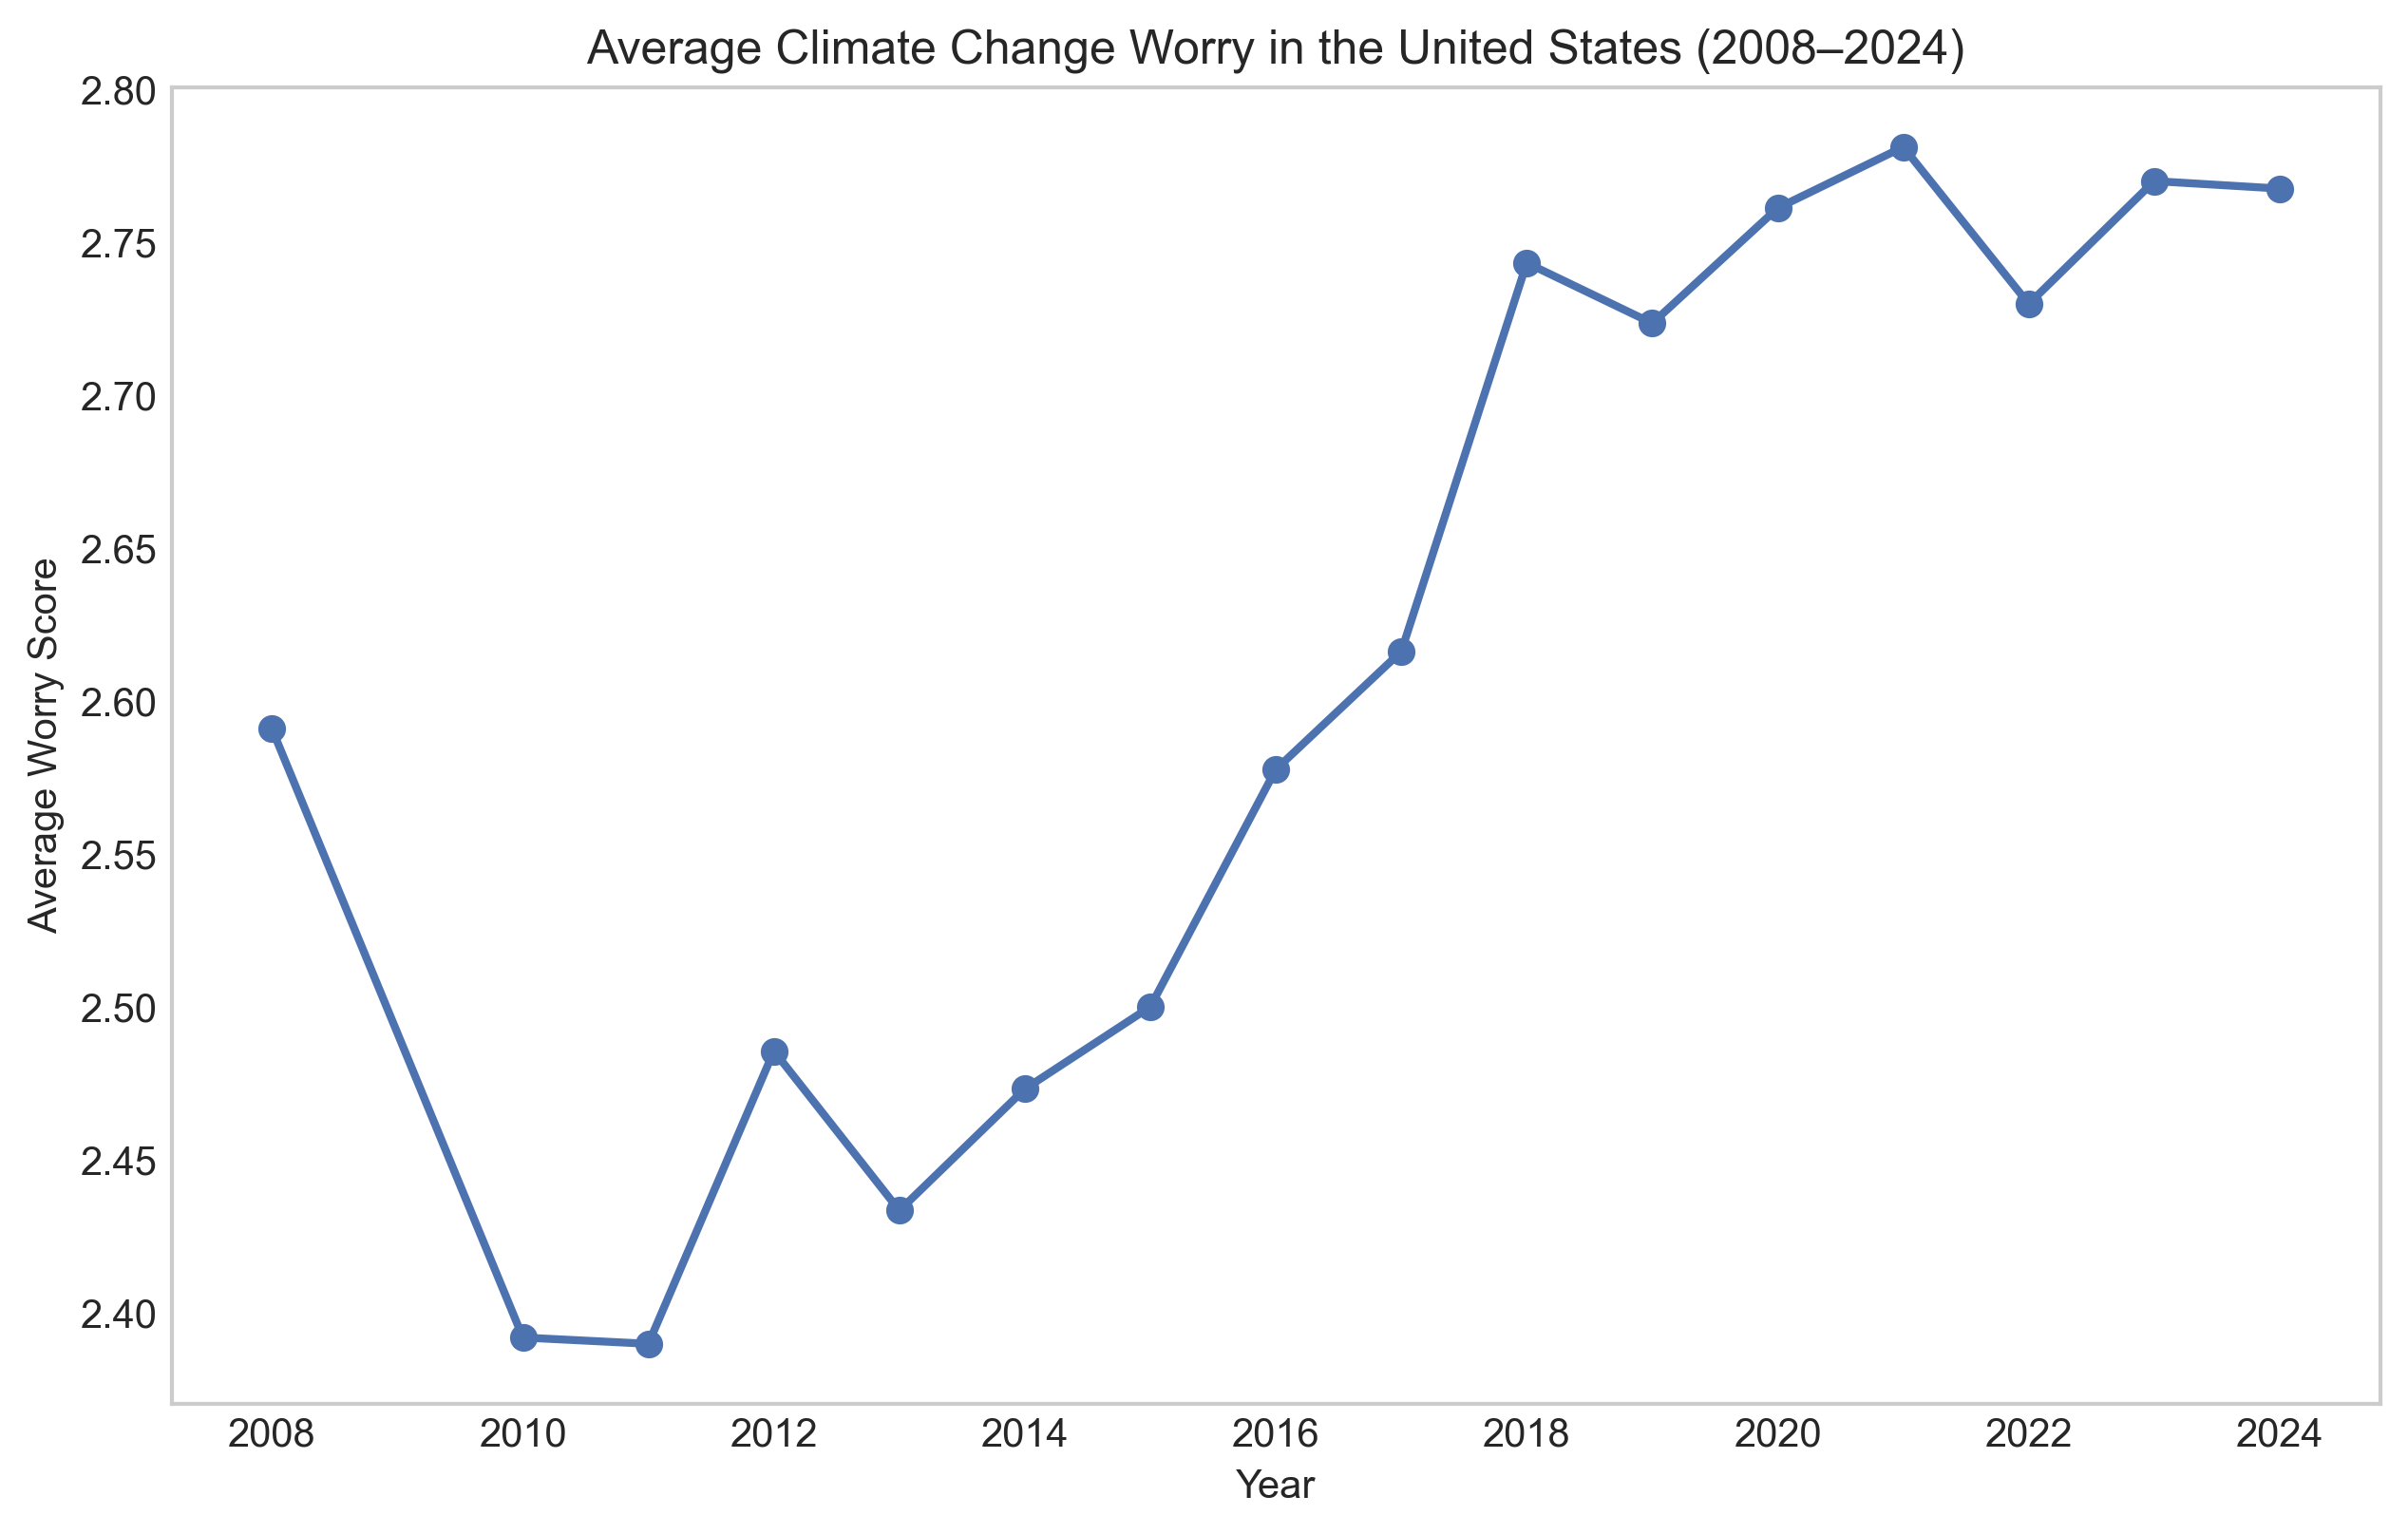

In [6]:
worry_by_year = df.groupby('year_actual')['worry'].mean()

plt.figure(figsize=(10,6), dpi = 300)
plt.plot(
    worry_by_year.index,
    worry_by_year.values,
    marker='o',
    linewidth=2
)

plt.title('Average Climate Change Worry in the United States (2008–2024)')
plt.xlabel('Year')
plt.ylabel('Average Worry Score')
plt.grid(False)
plt.show()

### Findings

Average climate worry increased over time, suggesting growing public concern regarding climate change.

In [7]:
early = df[df['year'] <= 5]['worry']
late = df[df['year'] >= 12]['worry']

ttest_ind(
    early.dropna(),
    late.dropna()
)

TtestResult(statistic=np.float64(-21.457987977864285), pvalue=np.float64(5.004449634708042e-101), df=np.float64(20440.0))

An independent samples t-test revealed a statistically significant increase in climate worry between 2008–2013 and 2020–2024, *t*(20,440) = -21.46, *p* < .001.

Respondents surveyed in later years reported significantly greater concern about climate change.

## Research Question 2

What groups do respondents believe are most affected by climate change?

In [8]:
harm_vars = [
    'harm_personally',
    'harm_US',
    'harm_future_gen',
    'harm_plants_animals'
]

harm_means = df[harm_vars].mean()
harm_means

harm_personally        2.056161
harm_US                2.450367
harm_future_gen        2.821887
harm_plants_animals    2.831072
dtype: float64

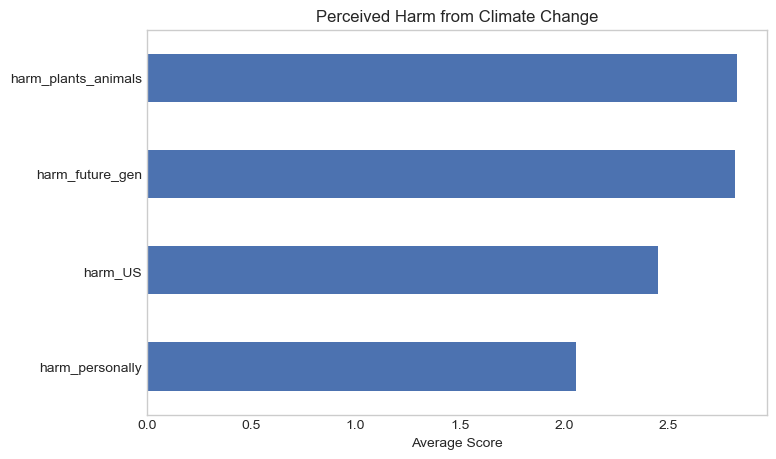

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
harm_means.sort_values().plot(kind='barh')

plt.title("Perceived Harm from Climate Change")
plt.xlabel("Average Score")
plt.grid(False)
plt.show()

### Results

Respondents perceived climate change as causing greater harm to future generations and natural ecosystems compared to themselves personally.

## Research Question 3

What factors are associated with support for climate-related policies?

In [10]:
policy_vars = [
    'fund_research',
    'reg_CO2_pollutant',
    'worry',
    'sci_consensus'
]

corr = df[policy_vars].corr()
corr

,fund_research,reg_CO2_pollutant,worry,sci_consensus
fund_research,1.000000,0.644045,0.449453,0.315568
reg_CO2_pollutant,0.644045,1.000000,0.525221,0.325701
worry,0.449453,0.525221,1.000000,0.452521
sci_consensus,0.315568,0.325701,0.452521,1.000000


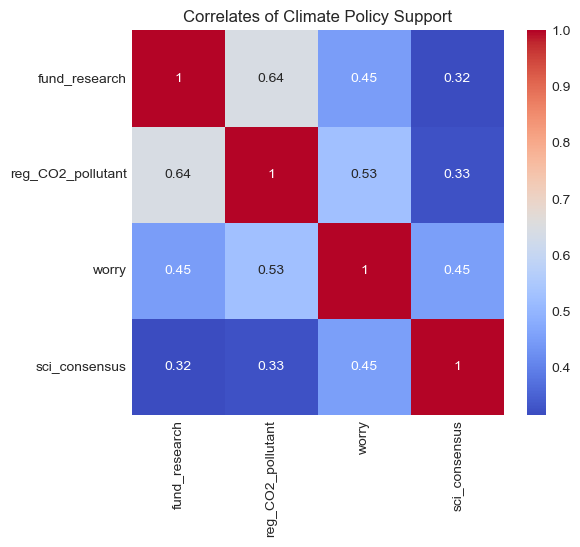

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlates of Climate Policy Support")
plt.show()

### Results

Climate worry and belief in scientific consensus were positively associated with support for climate policies such as carbon regulation and increased research funding.

## Conclusion

This analysis examined public attitudes toward climate change in the United States using data from the Yale Program on Climate Change Communication’s *Climate Change in the American Mind* survey (2008–2024).

Overall, the findings suggest that climate change concern has increased over time, with respondents in more recent years reporting higher levels of worry compared to earlier survey periods. In addition, respondents consistently perceived greater harm to future generations and natural ecosystems than to themselves personally, indicating a more collective and long-term framing of climate risk.

Finally, climate worry and belief in scientific consensus were both positively associated with support for climate-related policies, including carbon regulation and increased funding for climate research. This suggests that both emotional concern and scientific understanding play important roles in shaping public support for climate action.

Taken together, these results highlight not only growing concern about climate change over time, but also the importance of scientific trust and perceived risk in driving policy support. These insights may be useful for informing climate communication strategies and public engagement efforts aimed at increasing awareness and support for climate initiatives.